In [1]:
# Step 1: Import Required Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

from tensorflow.keras import models, layers

import numpy as np
import os
from matplotlib import pyplot as plt

In [2]:
def generate_small_square_image(size=28):
    img = np.zeros((size, size), dtype=np.uint8)
    start = size // 3
    end = start + size // 3
    img[start:end, start:end] = 255  # smaller square
    return img

def generate_large_square_image(size=28):
    img = np.zeros((size, size), dtype=np.uint8)
    start = size // 6
    end = start + size // 2
    img[start:end, start:end] = 255  # larger square
    return img

def generate_dataset(num_images_per_class=20, size=28):
    images = []
    labels = []
    
    for _ in range(num_images_per_class):
        small_square = generate_small_square_image(size)
        images.append(small_square)
        labels.append(0)  # Class 0 for small square
        
        large_square = generate_large_square_image(size)
        images.append(large_square)
        labels.append(1)  # Class 1 for large square
        
    images = np.array(images)
    labels = np.array(labels)
    return images, labels

# Generate dataset
images, labels = generate_dataset()

print("Dataset shape:", images.shape)
print("Labels shape:", labels.shape)

# Save sample images
os.makedirs("sample_images", exist_ok=True)
for i in range(5):
    plt.imsave(f"sample_images/small_square_{i}.png", images[i*2], cmap='gray')
    plt.imsave(f"sample_images/large_square_{i}.png", images[i*2+1], cmap='gray')

print("Sample images saved in 'sample_images' folder.")

Dataset shape: (40, 28, 28)
Labels shape: (40,)
Sample images saved in 'sample_images' folder.


In [3]:
# Step 2: Load Dataset into Training and Testing
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Split into training and testing sets
# xtrain, xtest

In [4]:
# Step 3: Preprocess Data
# Reshape input to include channel dimension (e.g. grayscale=1)
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32")/255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32")/255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [5]:
# Step 4: Build CNN Model
""" model = Sequential([
    Conv2D(filters, kernel_size, activation="activation_function", input_shape=(height, width, channels)),
    MaxPooling2D(pool_size=(pool_height, pool_width)),
    ... # additional Conv2D/Pooling layers
    Flatten(),
    Dense(units, activation="activation_function"),
    Dense(num_classes, activation="softmax")
]) """

model = models.Sequential([
    # layers.Conv2D(16, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.Input(shape=(28, 28, 1)), # Getting rid of the warning
    layers.Conv2D(16, (3, 3), activation="relu"),  # ← remove input_shape here
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    # layers.Dense(2, activation="softmax") # 2 classes small_square and large_square
    layers.Dense(10, activation="softmax") # ← fix
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 800)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 56,714 (221.54 KB)

 Trainable params: 56,714 (221.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Step 5: Compile the model
model.compile(optimizer="adam",
             loss="categorical_crossentropy",
             metrics=["accuracy"])

In [7]:
# Step 6: Train Model
history = model.fit(x_train, y_train,
                   validation_data=(x_test, y_test),
                   epochs=3,
                   batch_size=64)

Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.9339 - loss: 0.2211 - val_accuracy: 0.9794 - val_loss: 0.0651
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.9785 - loss: 0.0684 - val_accuracy: 0.9808 - val_loss: 0.0596
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9843 - loss: 0.0505 - val_accuracy: 0.9863 - val_loss: 0.0450


In [8]:
# Step 7: Evaluate the Model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")

313/313 - 2s - 7ms/step - accuracy: 0.9863 - loss: 0.0450

Test accuracy: 0.9863


In [9]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (60000, 28, 28, 1)
y_train shape: (60000, 10)
x_test shape: (10000, 28, 28, 1)
y_test shape: (10000, 10)


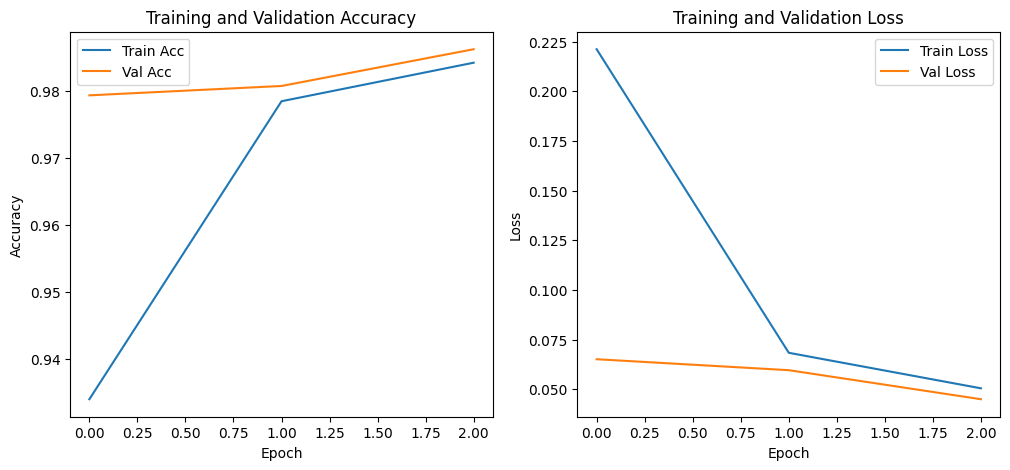

In [10]:
# Step 8: Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


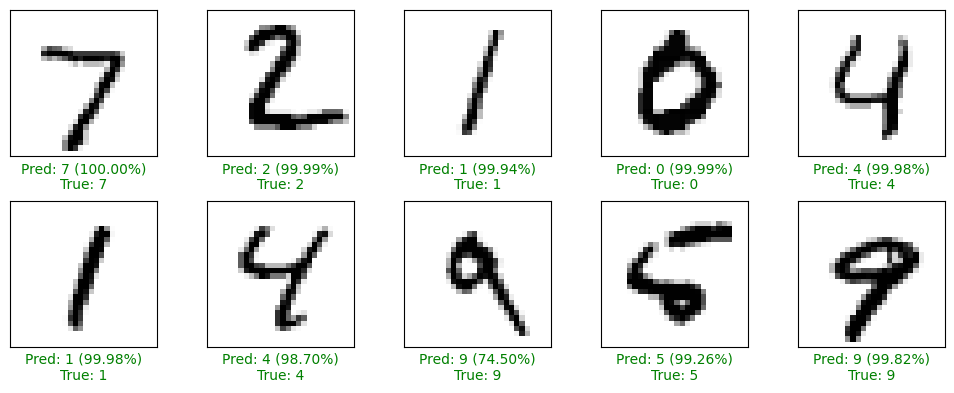

In [11]:
predictions = model.predict(x_test)

def plot_image(i, predictions_array, true_labels, images):
    predictions_array = predictions_array[i]
    true_label = np.argmax(true_labels[i]) if len(true_labels.shape) > 1 else true_labels[i]
    img = images[i].reshape(28, 28)

    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    color = "green" if predicted_label == true_label else "red"
    plt.xlabel(
        f"Pred: {predicted_label} ({100*np.max(predictions_array):.2f}%)\nTrue: {true_label}",
        color=color
    )

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plot_image(i, predictions, y_test, x_test)

plt.tight_layout()
plt.show()